# Comparing Machine Learning Models

This notebook trains and compares multiple machine learning models using a 70% training, 15% validation, and 15% testing split.

In [1]:
# Comparing Machine Learning Models
# Train / Validation / Test split: 70% / 15% / 15%

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# =========================
# 1) Load Dataset

In [3]:
# =========================

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset shape:", X.shape)
print("Target distribution:")
print(y.value_counts())
print("\nFirst 5 rows:")
print(X.head())

Dataset shape: (569, 30)
Target distribution:
target
1    357
0    212
Name: count, dtype: int64

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430

In [4]:
# =========================
# 2) Split Dataset
# 70% Train, 15% Validation, 15% Test

In [5]:
# =========================

# First split: 70% train and 30% temporary data
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: split the 30% temporary data into 15% validation and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nSplit sizes:")
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)


Split sizes:
Training set: (398, 30)
Validation set: (85, 30)
Test set: (86, 30)


In [6]:
# =========================
# 3) Preprocessing

In [7]:
# =========================

scaler = StandardScaler()

# Fit only on training data to avoid data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [8]:
# =========================
# 4) Define Models

In [9]:
# =========================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC()
}

In [10]:
# =========================
# 5) Train and Evaluate on Validation Set

In [11]:
# =========================

validation_results = []

for model_name, model in models.items():
    # Train the model using training data
    model.fit(X_train_scaled, y_train)

    # Predict validation data
    y_val_pred = model.predict(X_val_scaled)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred)
    recall = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)

    # Store results
    validation_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

validation_results_df = pd.DataFrame(validation_results)
validation_results_df = validation_results_df.sort_values(by="F1-Score", ascending=False)

print("\nValidation Results:")
print(validation_results_df)


Validation Results:
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.988235   1.000000  0.981132  0.990476
2        Random Forest  0.988235   1.000000  0.981132  0.990476
3                  SVM  0.976471   1.000000  0.962264  0.980769
1        Decision Tree  0.929412   0.979592  0.905660  0.941176


In [12]:
# =========================
# 6) Plot Validation Results

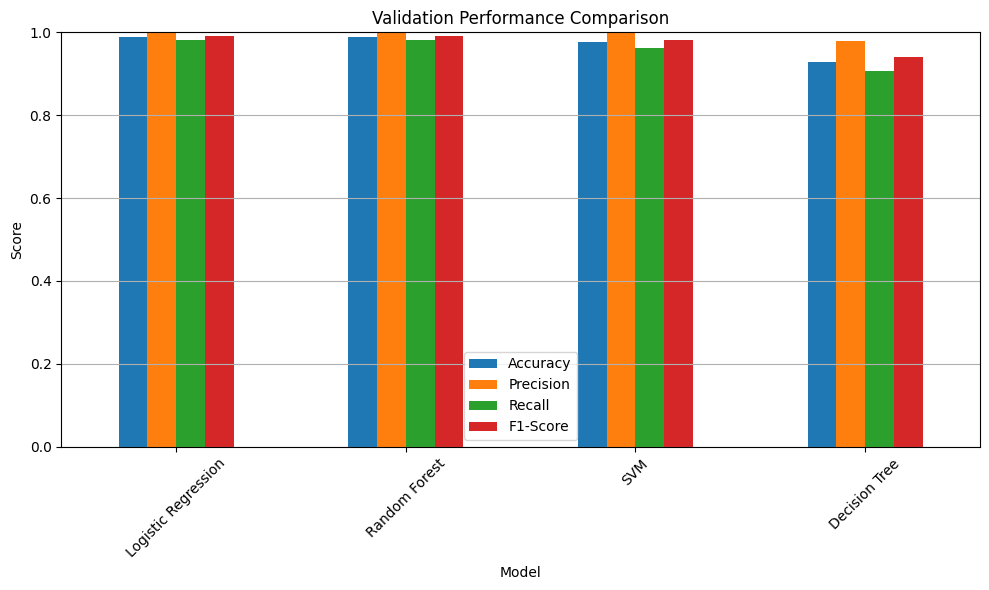

In [13]:
# =========================

validation_results_df.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1-Score"],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Validation Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [14]:
# =========================
# 7) Select Best Model Based on Validation F1-Score

In [15]:
# =========================

best_model_name = validation_results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("\nBest model based on validation F1-Score:", best_model_name)


Best model based on validation F1-Score: Logistic Regression


In [16]:
# =========================
# 8) Final Test Evaluation for the Best Model

In [17]:
# =========================

# The best model is already trained on X_train_scaled
# Now evaluate it on the test set only once

y_test_pred = best_model.predict(X_test_scaled)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

test_results_df = pd.DataFrame([{
    "Model": best_model_name,
    "Accuracy": test_accuracy,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1-Score": test_f1
}])

print("\nFinal Test Results for Best Model:")
print(test_results_df)


Final Test Results for Best Model:
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression  0.988372   0.981818     1.0  0.990826


In [18]:
# =========================
# 9) Confusion Matrix for Best Model on Test Set

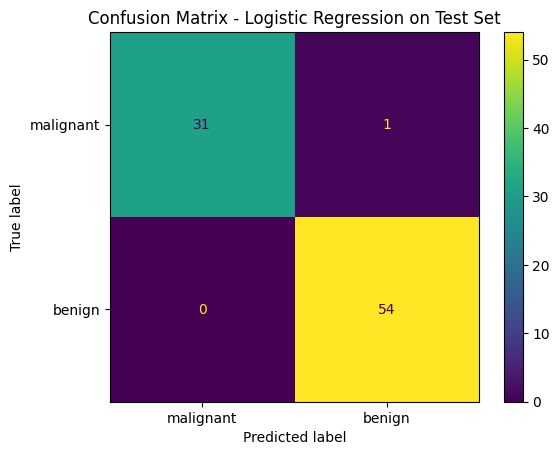

In [19]:
# =========================

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)

disp.plot()
plt.title(f"Confusion Matrix - {best_model_name} on Test Set")
plt.show()

In [20]:
# =========================
# 10) Optional: Confusion Matrices for All Models on Validation Set

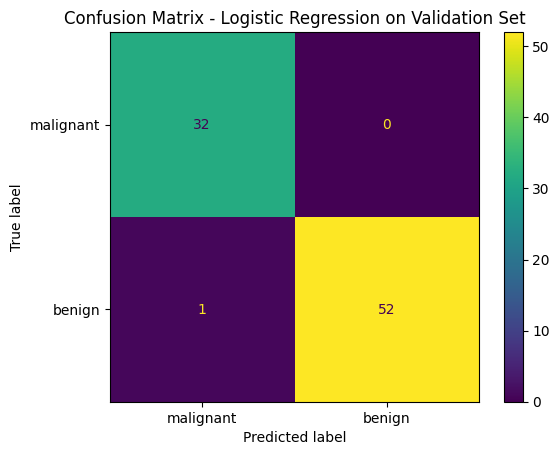

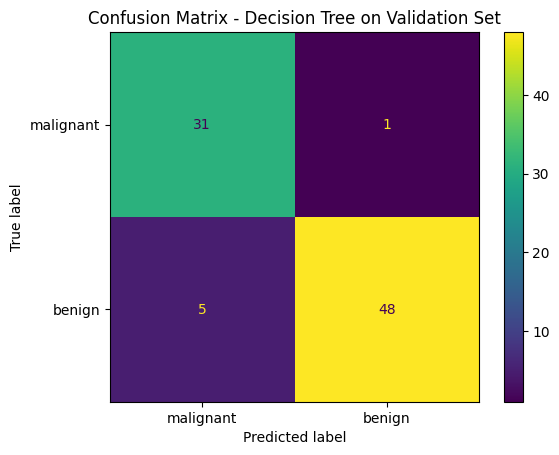

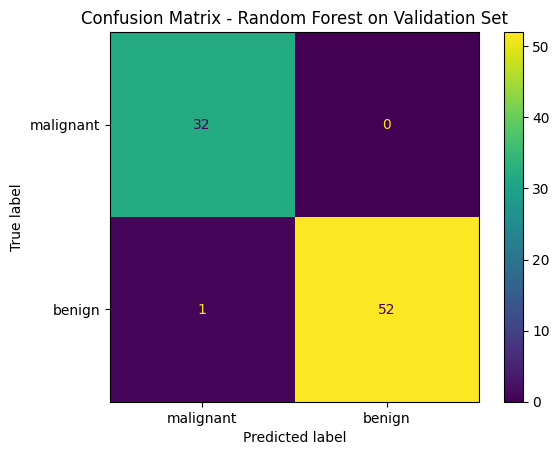

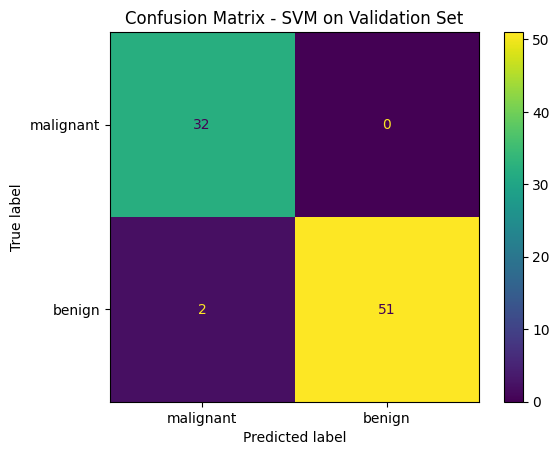

In [21]:
# =========================

for model_name, model in models.items():
    y_val_pred = model.predict(X_val_scaled)

    cm = confusion_matrix(y_val, y_val_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)

    disp.plot()
    plt.title(f"Confusion Matrix - {model_name} on Validation Set")
    plt.show()

In [ ]:
# The Logistic Regression model achieved the best performance based on the validation F1-score.
# It provided a strong balance between precision and recall, which makes it more reliable for classification tasks.
# Unlike Decision Tree, it did not suffer from overfitting, and it was more stable compared to Random Forest and SVM.

# Although Random Forest and SVM also showed strong performance, Logistic Regression was more consistent and computationally efficient.

# The test set was used only once for final evaluation to ensure a fair assessment and to avoid data leakage.